Question 1a.

Different optimizers can affect how fast and how well a neural network learns. Standard SGD (Stochastic Gradient Descent) updates model weights using gradients from small batches of data. It's simple but can be slow and may get stuck. SGD with Momentum improves on this by adding a “velocity” term that helps the model move more smoothly and escape shallow areas. AdaGrad adjusts the learning rate for each parameter based on past gradients, which works well for sparse data, but it can make learning stop too early. RMSProp fixes that by keeping a moving average of past squared gradients, so learning stays more stable. Adam combines both momentum and RMSProp ideas — it adapts learning rates for each parameter and speeds up training. Adam is very popular because it usually works well without much tuning and trains models faster and more reliably.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Training with SGD...
SGD Epoch 1: Loss=1.6667, Accuracy=59.14%
SGD Epoch 2: Loss=0.5425, Accuracy=85.69%
SGD Epoch 3: Loss=0.3958, Accuracy=88.94%
SGD Epoch 4: Loss=0.3469, Accuracy=90.11%
SGD Epoch 5: Loss=0.3175, Accuracy=90.95%
SGD Epoch 6: Loss=0.2943, Accuracy=91.58%
SGD Epoch 7: Loss=0.2741, Accuracy=92.13%
SGD Epoch 8: Loss=0.2564, Accuracy=92.64%
SGD Epoch 9: Loss=0.2401, Accuracy=93.18%
SGD Epoch 10: Loss=0.2252, Accuracy=93.60%
Training with Momentum...
Momentum Epoch 1: Loss=0.5479, Accuracy=84.32%
Momentum Epoch 2: Loss=0.1987, Accuracy=94.22%
Momentum Epoch 3: Loss=0.1328, Accuracy=96.11%
Momentum Epoch 4: Loss=0.0996, Accuracy=96.99%
Momentum Epoch 5: Loss=0.0780, Accuracy=97.67%
Momentum Epoch 6: Loss=0.0628, Accuracy=98.08%
Momentum Epoch 7: Loss=0.0518, Accuracy=98.45%
Momentum Epoch 8: Loss=0.0439, Accuracy=98.65%
Momentum Epoch 9: Loss=0.0356, Accuracy=98.94%
Momentum Epoch 10: Loss=0.0313, Accuracy=99.09%
Training with AdaGrad...
AdaGrad Epoch 1: Loss=0.2849, Accura

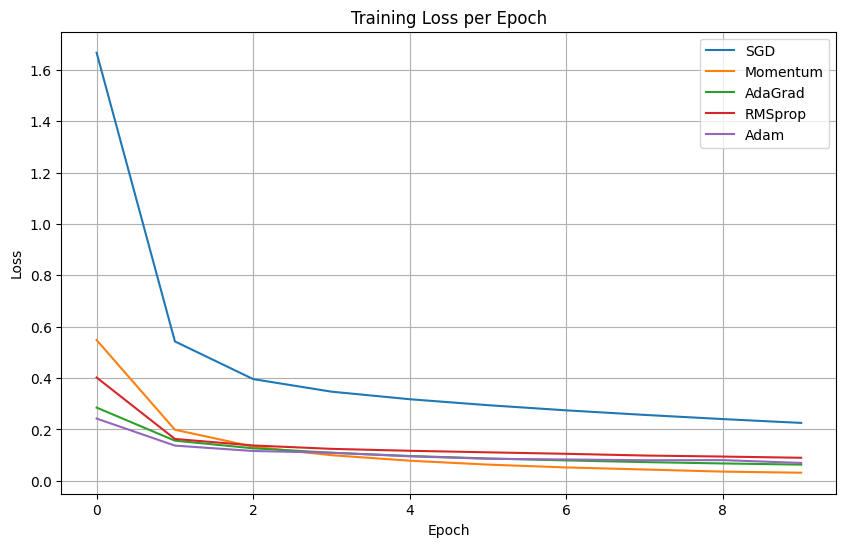

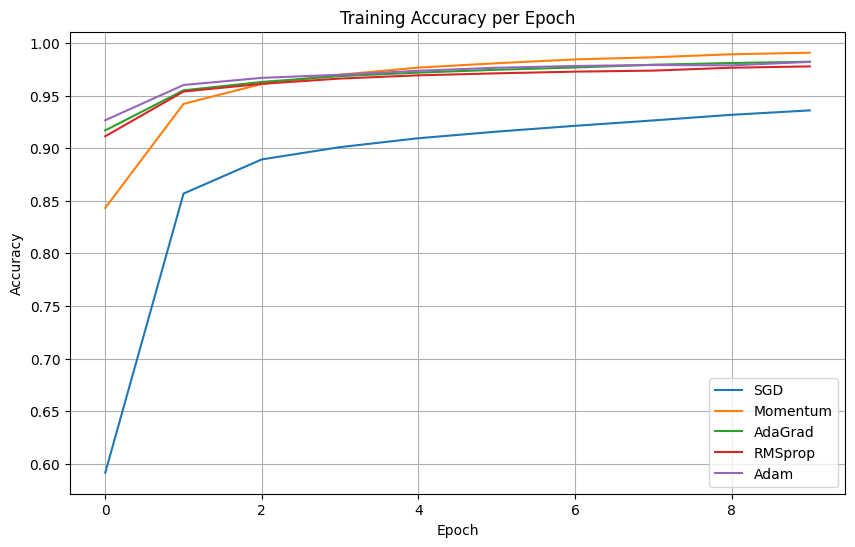

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 50)
        self.fc3 = nn.Linear(50, 10)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # No softmax here; use CrossEntropyLoss instead
        return x

transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

def train_model(optimizer_name, epochs=5, lr=0.01, momentum=0.9):
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    elif optimizer_name == 'AdaGrad':
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f"{optimizer_name} Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc*100:.2f}%")

    return train_losses, train_accuracies


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

optimizers = ['SGD', 'Momentum', 'AdaGrad', 'RMSprop', 'Adam']
results = {}

all_losses = {}
all_accuracies = {}

for opt in optimizers:
    print(f"Training with {opt}...")
    losses, accs = train_model(opt, epochs=10)  # Increase epochs if you'd like
    all_losses[opt] = losses
    all_accuracies[opt] = accs

def plot_metrics(metric_dict, title, ylabel):
    plt.figure(figsize=(10, 6))
    for opt_name, values in metric_dict.items():
        plt.plot(values, label=opt_name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metrics(all_losses, "Training Loss per Epoch", "Loss")
plot_metrics(all_accuracies, "Training Accuracy per Epoch", "Accuracy")


Epoch [100/4000], MLP Loss: 0.1005, Fourier Loss: 0.1595
Epoch [200/4000], MLP Loss: 0.0425, Fourier Loss: 0.0520
Epoch [300/4000], MLP Loss: 0.0407, Fourier Loss: 0.0407
Epoch [400/4000], MLP Loss: 0.0390, Fourier Loss: 0.0395
Epoch [500/4000], MLP Loss: 0.0385, Fourier Loss: 0.0388
Epoch [600/4000], MLP Loss: 0.0381, Fourier Loss: 0.0382
Epoch [700/4000], MLP Loss: 0.0378, Fourier Loss: 0.0373
Epoch [800/4000], MLP Loss: 0.0375, Fourier Loss: 0.0354
Epoch [900/4000], MLP Loss: 0.0370, Fourier Loss: 0.0329
Epoch [1000/4000], MLP Loss: 0.0366, Fourier Loss: 0.0299
Epoch [1100/4000], MLP Loss: 0.0361, Fourier Loss: 0.0263
Epoch [1200/4000], MLP Loss: 0.0323, Fourier Loss: 0.0224
Epoch [1300/4000], MLP Loss: 0.0296, Fourier Loss: 0.0191
Epoch [1400/4000], MLP Loss: 0.0300, Fourier Loss: 0.0164
Epoch [1500/4000], MLP Loss: 0.0277, Fourier Loss: 0.0145
Epoch [1600/4000], MLP Loss: 0.0254, Fourier Loss: 0.0136
Epoch [1700/4000], MLP Loss: 0.0246, Fourier Loss: 0.0116
Epoch [1800/4000], MLP 

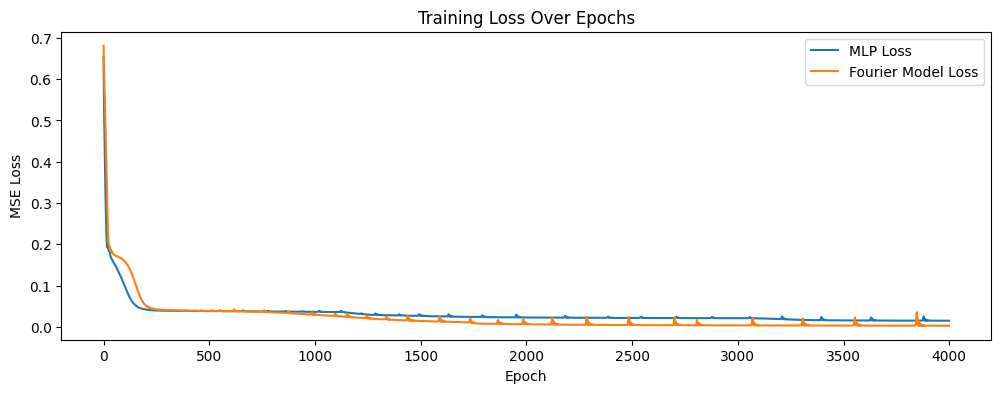

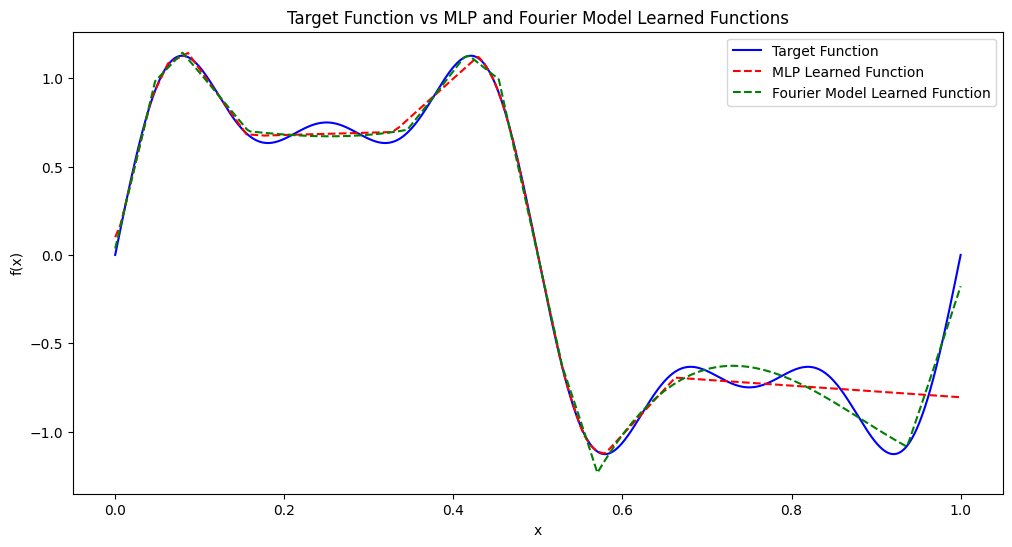

In [1]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Define the target function as the sum of 3 sinusoids
def target_function(x):
    return np.sin(2 * np.pi * 1.0 * x) + 0.5 * np.sin(2 * np.pi * 3.0 * x) + 0.25 * np.sin(2 * np.pi * 5.0 * x)

# Generate dataset with 4000 points
x = np.linspace(0, 1, 4000)  # 4000 points between 0 and 1
y = target_function(x)

# Convert to PyTorch tensors
x_train = torch.tensor(x, dtype=torch.float32).view(-1, 1)
y_train = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Define the original 3-layer MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(1, 100)
        self.fc2 = nn.Linear(100, 100)
        self.fc3 = nn.Linear(100, 1)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

# Define the LFF (Learnable Fourier Feature) layer
class LFF(nn.Module):
    def __init__(self, in_features, out_features, scale=1.0, init="iso", sincos=False):
        super().__init__()
        self.in_features = in_features
        self.sincos = sincos
        self.out_features = out_features
        self.scale = scale
        if self.sincos:
            self.linear = nn.Linear(in_features, out_features // 2)
        else:
            self.linear = nn.Linear(in_features, out_features)
        if init == "iso":
            nn.init.normal_(self.linear.weight, 0, scale / in_features)
            nn.init.normal_(self.linear.bias, 0, 1)
        else:
            nn.init.uniform_(self.linear.weight, -scale / in_features, scale / in_features)
            nn.init.uniform_(self.linear.bias, -1, 1)
        if self.sincos:
            nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        x = np.pi * self.linear(x)
        if self.sincos:
            return torch.cat([torch.sin(x), torch.cos(x)], dim=-1)
        else:
            return torch.sin(x)

# Define the FourierModel with the LFF layer
class FourierModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(FourierModel, self).__init__()
        self.input_layer = LFF(state_dim, hidden_dim, scale=0.1, init="iso", sincos=False)
        self.mid_layer = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.mid_layer(x)
        x = self.relu2(x)
        return self.output(x)

# Initialize models, loss function, and optimizers
mlp_model = MLP()
fourier_model = FourierModel(state_dim=1, action_dim=1, hidden_dim=100)

criterion = nn.MSELoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.002)
fourier_optimizer = optim.Adam(fourier_model.parameters(), lr=0.002)

# Training loop for both models
num_epochs = 4000
mlp_losses = []
fourier_losses = []

for epoch in range(num_epochs):
    # Train MLP model
    mlp_model.train()
    mlp_optimizer.zero_grad()
    mlp_y_pred = mlp_model(x_train)
    mlp_loss = criterion(mlp_y_pred, y_train)
    mlp_loss.backward()
    mlp_optimizer.step()
    mlp_losses.append(mlp_loss.item())

    # Train Fourier model
    fourier_model.train()
    fourier_optimizer.zero_grad()
    fourier_y_pred = fourier_model(x_train)
    fourier_loss = criterion(fourier_y_pred, y_train)
    fourier_loss.backward()
    fourier_optimizer.step()
    fourier_losses.append(fourier_loss.item())

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], MLP Loss: {mlp_loss.item():.4f}, Fourier Loss: {fourier_loss.item():.4f}")

# Plot the training loss for both models
plt.figure(figsize=(12, 4))
plt.plot(mlp_losses, label="MLP Loss")
plt.plot(fourier_losses, label="Fourier Model Loss")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# Plot the target function vs. the learned functions
with torch.no_grad():
    mlp_y_learned = mlp_model(x_train).numpy()
    fourier_y_learned = fourier_model(x_train).numpy()

plt.figure(figsize=(12, 6))
plt.plot(x, y, label="Target Function", color='blue')
plt.plot(x, mlp_y_learned, label="MLP Learned Function", color='red', linestyle='--')
plt.plot(x, fourier_y_learned, label="Fourier Model Learned Function", color='green', linestyle='--')
plt.title("Target Function vs MLP and Fourier Model Learned Functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In this problem, we compare two neural network models—a standard MLP and a Fourier-based model—both designed to approximate a target function from input data. The input to both models is a single real-valued scalar 𝑥, and the output is the model's prediction of the function value f(x). The key difference between the models lies in the use of a special layer in the Fourier model called the LFF (Linear Fourier Features) layer. This layer transforms the input by applying sine and cosine functions to a random linear projection of the input, effectively mapping it into a higher-frequency feature space. This transformation helps the model represent more complex, high-frequency patterns that a regular MLP might struggle to learn efficiently. When running the code, we observe that the Fourier model typically fits the target function more accurately, especially if the function has rapid variations. This aligns with the Universal Approximation Theorem, which states that neural networks can approximate any continuous function given enough capacity. However, in practice, architectures like the Fourier model can approximate certain functions more efficiently by incorporating prior knowledge—such as periodicity—through feature transformations like those in the LFF layer.